In [37]:
import pandas as pd
import requests 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use('default') # sets matplotlib to use default plotting style
sns.set_context('talk') # Used for clarity in project



In [38]:
# Load the Met Eireann Station CSV file
# Used engine python and on bad lines skip as Met Eireann Data coming up with error on loading file
df = pd.read_csv(
    'StationDetails.csv',
    engine='python',
    on_bad_lines='skip'
)

# Inspect Columns
print(df.shape)
print(df.columns)

(2080, 10)
Index(['county', 'station name', 'name', 'height(m)', 'easting', 'northing',
       'latitude', 'longitude', 'open year', 'close year'],
      dtype='object')


In [ ]:
#Due to the structure of Met Éireann’s observational data, a subset of representative stations was selected to analyse rainfall and wind trends.

stations = {"Cork Airport": "cork%20airport",
            "Dublin Airport": "dublin%20airport",
            "Shannon Airport": "shannon%20airport",
            "Knock Airport": "knock%20airport",
            "Valentia Observatory": "valentia%20observatory" }

In [40]:
# Fetch and parse rainfall data

def fetch_rainfall_data(station_name, station_url):
    url = f'https://prodapi.metweb.ie/monthly-data/{station_url}'
    response = requests.get(url)
    data = response.json()

    rainfall = data['total_rainfall']['report']

    records =[]

    for year in ['2024', '2025']:
        if year in rainfall:
            for month, value in rainfall[year].items():
                if month != 'annual' and value not in ['','n/a']:
                    records.append({
                        'station': station_name,
                        'year': int(year),
                        'month': month,
                        'rainfall_mm': float(value)

                })
                    
    return pd.DataFrame(records)


In [41]:
# Pull data from all stations

df_list = []

for station_name, station_url in stations.items():
    df_station = fetch_rainfall_data (station_name, station_url)
    df_list.append(df_station)

rainfall_df = pd.concat(df_list, ignore_index=True)

In [42]:
# Inspet the result

print(rainfall_df.info())
rainfall_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   station      120 non-null    object 
 1   year         120 non-null    int64  
 2   month        120 non-null    object 
 3   rainfall_mm  120 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.9+ KB
None


,station,year,month,rainfall_mm
0,Cork Airport,2024,january,99.5
1,Cork Airport,2024,february,157.7
2,Cork Airport,2024,mar,168.2
3,Cork Airport,2024,apr,107.1
4,Cork Airport,2024,may,109.6


In [43]:
# Compare 2024 vs 2025

yearly_comparison = (
    rainfall_df
    .groupby(['station', 'year'])['rainfall_mm']
    .mean()
    .reset_index()
)

yearly_comparison

,station,year,rainfall_mm
0,Cork Airport,2024,105.833333
1,Cork Airport,2025,114.366667
2,Dublin Airport,2024,55.833333
3,Dublin Airport,2025,67.016667
4,Knock Airport,2024,119.175000
5,Knock Airport,2025,114.583333
6,Shannon Airport,2024,81.150000
7,Shannon Airport,2025,85.666667
8,Valentia Observatory,2024,137.691667
9,Valentia Observatory,2025,150.783333


In [ ]:
# Indenify extreme rainfall months

# No extreme rainfall in cork 2024 compared to 2025 - 2025 more extreme wet months 

threshold = rainfall_df['rainfall_mm'].quantile(0.90)

extreme_rainfall = (

 rainfall_df
 .groupby('station', group_keys=False)
 .apply(lambda x: x[x['rainfall_mm'] >= x['rainfall_mm'].quantile(0.90)])
)

extreme_rainfall = extreme_rainfall.sort_values(
    by=['station', 'year', 'rainfall_mm'],
    ascending=[True, True, False]
)


extreme_rainfall

C:\Users\Administrator\AppData\Local\Temp\ipykernel_18160\173004812.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[x['rainfall_mm'] >= x['rainfall_mm'].quantile(0.90)])


,station,year,month,rainfall_mm
13,Cork Airport,2025,february,213.4
22,Cork Airport,2025,november,203.7
21,Cork Airport,2025,october,176.5
26,Dublin Airport,2024,mar,115.4
46,Dublin Airport,2025,november,119.1
44,Dublin Airport,2025,september,91.4
79,Knock Airport,2024,august,215.4
93,Knock Airport,2025,october,175.0
92,Knock Airport,2025,september,173.5
49,Shannon Airport,2024,february,156.5


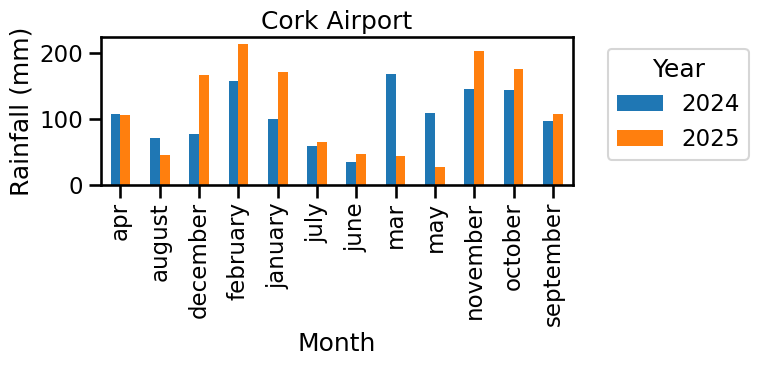

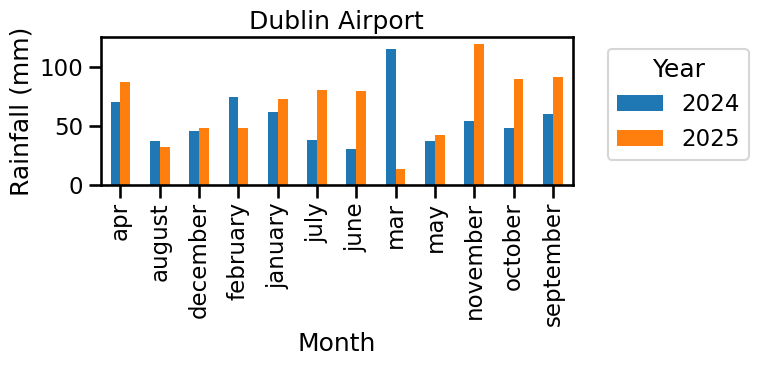

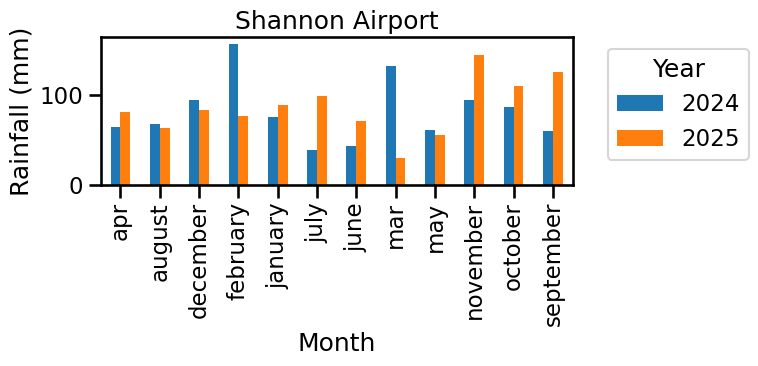

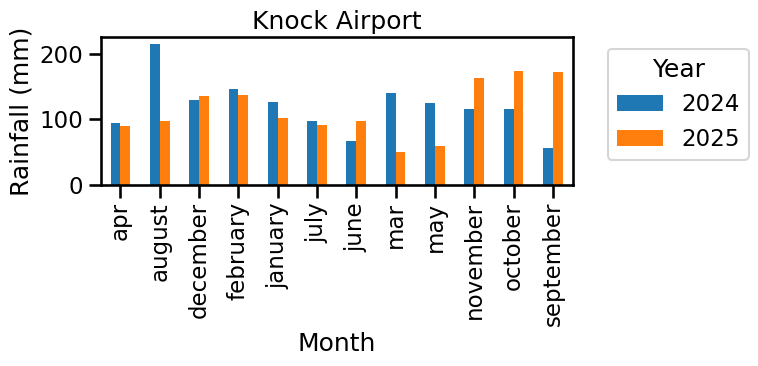

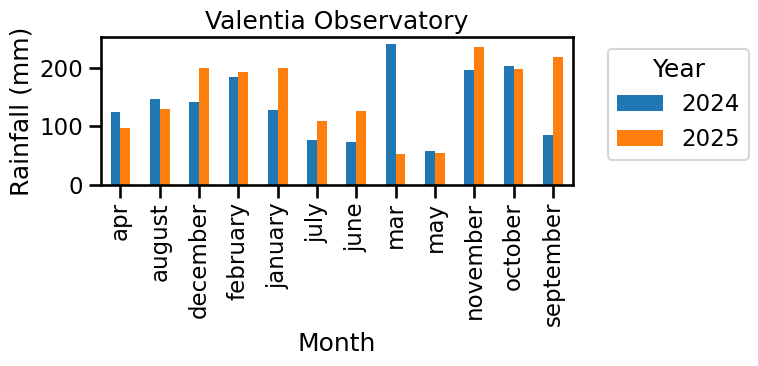

In [62]:
# Visualise data using matlpotlib

for station in rainfall_df['station'].unique():
    subset = rainfall_df[rainfall_df['station'] == station]

    pivot = subset.pivot(
        index='month',
        columns='year',
        values='rainfall_mm'
    )

    ax = pivot.plot(kind='bar', figsize=(8,4), title=station)

    ax.set_ylabel('Rainfall (mm)')
    ax.set_xlabel('Month')

# Forcing legend to stay to right side as cork graph was showing in middle
    ax.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()


In [51]:

national_summary = (
    rainfall_df
    .groupby('year')['rainfall_mm']
    .mean()
    .reset_index(name='mean_monthly_rainfall_mm')
)

national_summary



,year,mean_monthly_rainfall_mm
0,2024,99.936667
1,2025,106.483333


In [ ]:
# While mean rainfall between 2024 and 2025 shows only modest differences, the data indicates an increase in the frequency and intensity of extreme rainfall months in 2025, 
# particularly at western and coastal stations such as Valentia Observatory and Cork Airport. 
# This suggests greater rainfall variability and storm impact in 2025 rather than a uniform increase in annual rainfall.